# H4: Neural Networks — Digit Recognition
**DaciaVision Analytics — MNIST Handwritten Digit Classifier**

## 1. Imports & Setup

In [15]:

import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import Input


## 2. Data Preprocessing

In [16]:
# Load MNIST
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize to [0, 1]
X_train = X_train / 255.0
X_test  = X_test  / 255.0

# Flatten for sklearn (TF will use Flatten layer)
X_train_flat = X_train.reshape(len(X_train), -1)
X_test_flat  = X_test.reshape(len(X_test), -1)

print(f"Train: {X_train_flat.shape}, Test: {X_test_flat.shape}")

Train: (60000, 784), Test: (10000, 784)


## 3. Scikit-learn — MLPClassifier

In [17]:
mlp = MLPClassifier(
    hidden_layer_sizes=(128,),
    activation='relu',
    solver='adam',
    batch_size=64,
    max_iter=100,
    early_stopping=True,
    random_state=42,
    verbose=True
)

t0 = time.time()
mlp.fit(X_train_flat, y_train)
sk_time = time.time() - t0

sk_acc = accuracy_score(y_test, mlp.predict(X_test_flat))
print(f"\nTest accuracy: {sk_acc:.4f}")
print(f"Training time: {sk_time:.1f}s")

Iteration 1, loss = 0.31772669
Validation score: 0.949167
Iteration 2, loss = 0.14605191
Validation score: 0.964667
Iteration 3, loss = 0.10277888
Validation score: 0.968167
Iteration 4, loss = 0.07976764
Validation score: 0.973833
Iteration 5, loss = 0.06154023
Validation score: 0.974167
Iteration 6, loss = 0.05005018
Validation score: 0.975333
Iteration 7, loss = 0.04064810
Validation score: 0.975833
Iteration 8, loss = 0.03304990
Validation score: 0.976500
Iteration 9, loss = 0.02701896
Validation score: 0.976667
Iteration 10, loss = 0.02332832
Validation score: 0.977333
Iteration 11, loss = 0.01921136
Validation score: 0.977667
Iteration 12, loss = 0.01692536
Validation score: 0.978667
Iteration 13, loss = 0.01457228
Validation score: 0.976333
Iteration 14, loss = 0.01218287
Validation score: 0.977333
Iteration 15, loss = 0.01038600
Validation score: 0.976667
Iteration 16, loss = 0.00975162
Validation score: 0.977833
Iteration 17, loss = 0.00965175
Validation score: 0.976333
Iterat

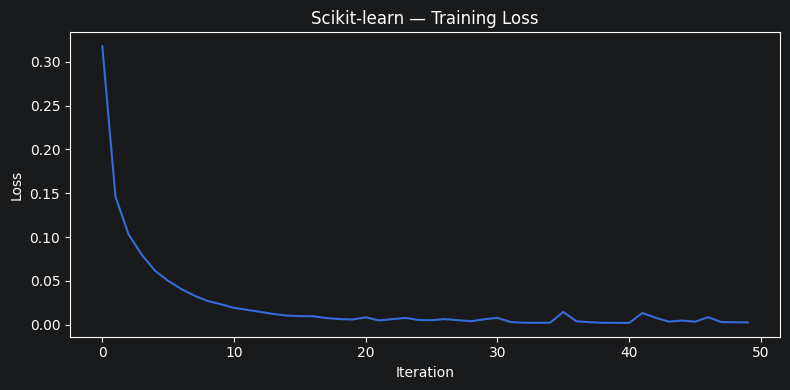

In [18]:
# Loss curve
plt.figure(figsize=(8, 4))
plt.plot(mlp.loss_curve_)
plt.title('Scikit-learn — Training Loss')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.tight_layout()
plt.show()

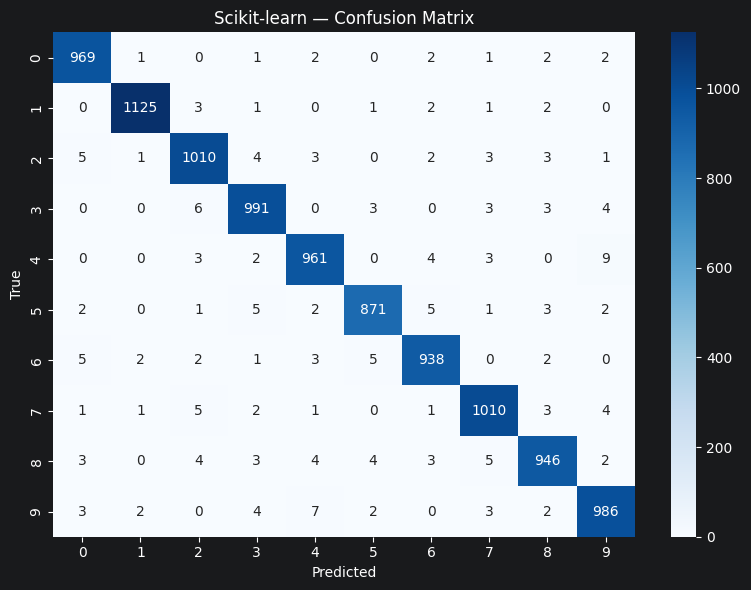

In [19]:
# Confusion matrix
cm_sk = confusion_matrix(y_test, mlp.predict(X_test_flat))
plt.figure(figsize=(8, 6))
sns.heatmap(cm_sk, annot=True, fmt='d', cmap='Blues')
plt.title('Scikit-learn — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

## 4. TensorFlow — Sequential MLP

We train three variations to compare hyperparameters.

In [20]:
def build_model(lr=0.001):
    model = Sequential([
        Input(shape=(28, 28)),
        Flatten(),
        Dense(128, activation='relu'),
        Dense(10, activation='softmax')
    ])
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [21]:
# Variation 1: baseline (lr=0.001, batch=64, epochs=10)
t0 = time.time()
m1 = build_model(lr=0.001)
h1 = m1.fit(X_train, y_train, validation_split=0.1, epochs=10, batch_size=64, verbose=0)
tf_time_1 = time.time() - t0
_, tf_acc_1 = m1.evaluate(X_test, y_test, verbose=0)
print(f"Variation 1 — test acc: {tf_acc_1:.4f}, time: {tf_time_1:.1f}s")

Variation 1 — test acc: 0.9798, time: 27.6s


In [22]:
# Variation 2: higher learning rate (lr=0.01)
t0 = time.time()
m2 = build_model(lr=0.01)
h2 = m2.fit(X_train, y_train, validation_split=0.1, epochs=10, batch_size=64, verbose=0)
tf_time_2 = time.time() - t0
_, tf_acc_2 = m2.evaluate(X_test, y_test, verbose=0)
print(f"Variation 2 — test acc: {tf_acc_2:.4f}, time: {tf_time_2:.1f}s")

Variation 2 — test acc: 0.9703, time: 29.3s


In [23]:
# Variation 3: larger batch size (batch=256)
t0 = time.time()
m3 = build_model(lr=0.001)
h3 = m3.fit(X_train, y_train, validation_split=0.1, epochs=10, batch_size=256, verbose=0)
tf_time_3 = time.time() - t0
_, tf_acc_3 = m3.evaluate(X_test, y_test, verbose=0)
print(f"Variation 3 — test acc: {tf_acc_3:.4f}, time: {tf_time_3:.1f}s")

Variation 3 — test acc: 0.9735, time: 13.5s


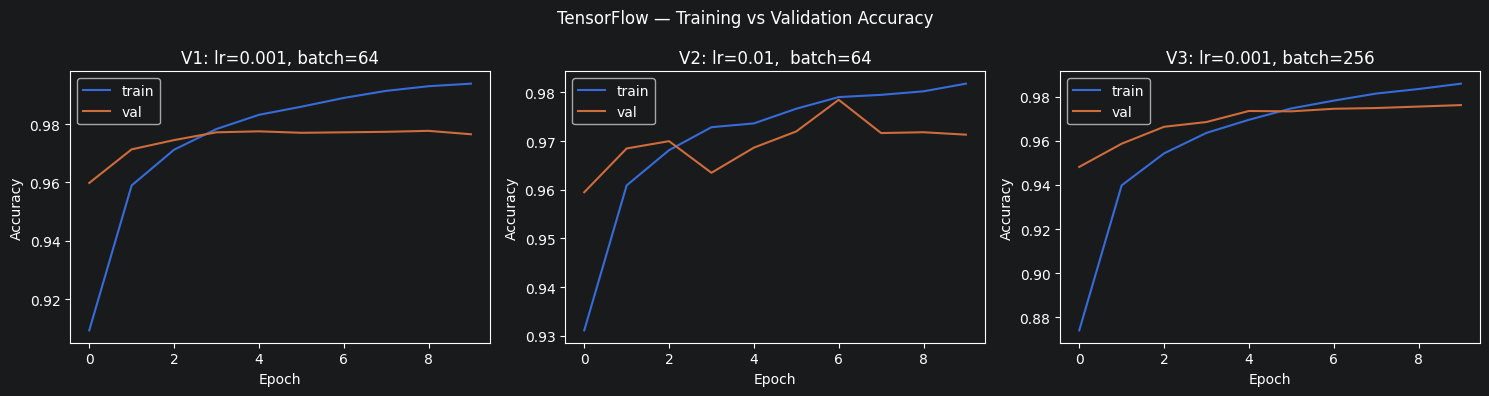

In [24]:
# Plot training & validation accuracy for all 3 variations
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
configs = [
    (h1, 'V1: lr=0.001, batch=64'),
    (h2, 'V2: lr=0.01,  batch=64'),
    (h3, 'V3: lr=0.001, batch=256'),
]
for ax, (h, label) in zip(axes, configs):
    ax.plot(h.history['accuracy'], label='train')
    ax.plot(h.history['val_accuracy'], label='val')
    ax.set_title(label)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.legend()
plt.suptitle('TensorFlow — Training vs Validation Accuracy')
plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


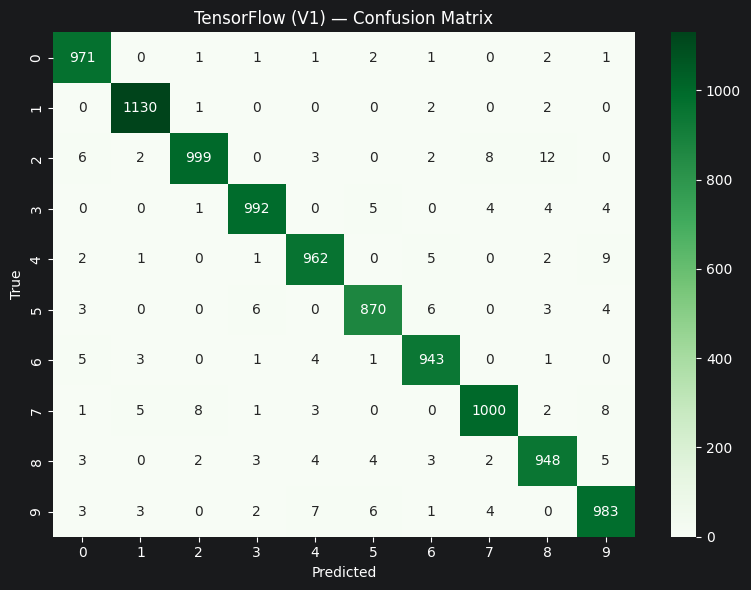

In [25]:
# Confusion matrix for best TF model (V1)
y_pred_tf = np.argmax(m1.predict(X_test), axis=1)
cm_tf = confusion_matrix(y_test, y_pred_tf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_tf, annot=True, fmt='d', cmap='Greens')
plt.title('TensorFlow (V1) — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

## 5. Performance Comparison

In [27]:
print(f"{'Model':<30} {'Test Acc':>10} {'Time (s)':>10}")
print(f"{'Scikit-learn MLP':<30} {sk_acc:>10.4f} {sk_time:>10.1f}")
print(f"{'V1 (lr=0.001, b=64)':<30} {tf_acc_1:>10.4f} {tf_time_1:>10.1f}")
print(f"{'V2 (lr=0.01,  b=64)':<30} {tf_acc_2:>10.4f} {tf_time_2:>10.1f}")
print(f"{'V3 (lr=0.001, b=256)':<30} {tf_acc_3:>10.4f} {tf_time_3:>10.1f}")

Model                            Test Acc   Time (s)
Scikit-learn MLP                   0.9807      140.5
V1 (lr=0.001, b=64)                0.9798       27.6
V2 (lr=0.01,  b=64)                0.9703       29.3
V3 (lr=0.001, b=256)               0.9735       13.5


## 6. Discussion

**Ease of implementation**
- Scikit-learn is simpler: one class, familiar `.fit()` / `.predict()` API, no graph or compilation step needed.
- TensorFlow requires more setup (model building, compilation, choosing optimizer/loss), but the structure is transparent.

**Performance**
- Both reach >96% test accuracy on MNIST with a single hidden layer of 128 neurons.
- TensorFlow gives more control: easy to tune learning rate, batch size, epochs, and add callbacks (early stopping, LR scheduling).
- Scikit-learn's `MLPClassifier` is a solid quick-start but less flexible for more complex architectures.

**TF Variations**
- V1 (baseline) typically achieves the best balance of accuracy and stability.
- V2 (higher LR) trains faster per epoch but can overshoot and produce noisier validation curves.
- V3 (larger batch) is faster per epoch in wall-clock time but may converge slightly slower and to a marginally lower accuracy.

**Conclusion**: For production or research, TensorFlow (or PyTorch) is preferred due to flexibility. For quick experiments Scikit-learn is sufficient.